# **Analysis: Vanguards-lite Realistic Scenario (No Forced Adversarial L2)**

This notebook analyzes the realistic Vanguards-lite scenario where L2 guards are selected without forcing at least one adversarial relay. This represents the real-world impact of Vanguards-lite on users without adversarial L2 control.

In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from glob import glob
from os.path import join, abspath
from matplotlib.lines import Line2D

## Section 1: Load and Parse Simulation Results

Load JSON simulation result files from the countermeasures_logs_nol2guard directory.

In [2]:
DATA_DIR = abspath("../data/countermeasures_logs_nol2guard")

def load_from_json(json_path):
    return json.loads(open(json_path).read())

def load_sim_results(json_path, attack_times):
    """Load simulation results and extract metadata."""
    res = load_from_json(json_path)
    
    # Pretty-format the adversary-controlled share of HSDirs
    h = "-1"
    if res["n_adv_hsdirs"] == 1:
        h = "1/6"
    elif res["n_adv_hsdirs"] == 2:
        h = "1/3"
    elif res["n_adv_hsdirs"] == 6:
        h = "1"
    
    # Pretty-format the adversarial relay bandwidth share
    b = "%d%%" % (100 * float(res["adv_bw_share"]))
    
    # Extract defense parameters
    tb_iv = res["n_initial_tokens"]
    tb_refill = res["token_refill_rate"]
    vanguardslite_enabled = res.get("vanguardslite_enabled", False)
    
    # Append each attack duration with metadata
    for timestamp in res["attack_durations"]:
        attack_times.append((h, b, tb_iv, tb_refill, vanguardslite_enabled, timestamp))

# Load all JSON results
attack_times = []
for json_path in glob(join(DATA_DIR, "time_to_double_comp_*.json")):
    load_sim_results(json_path, attack_times)

print(f"Loaded {len(attack_times)} attack duration samples")

Loaded 300 attack duration samples


## Section 2: Aggregate Simulation Data

Create a pandas DataFrame and group by simulation parameters.

In [3]:
df = pd.DataFrame(
    attack_times, 
    columns=["h", "b", "tb_iv", "tb_refill", "vanguardslite_enabled", "attack_duration"]
)

print("DataFrame shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print("\nData summary:")
print(f"Unique h values: {sorted(df['h'].unique())}")
print(f"Unique b values: {sorted(df['b'].unique())}")
print(f"Vanguards-lite enabled: {df['vanguardslite_enabled'].unique()}")

DataFrame shape: (300, 6)

First 10 rows:
   h   b  tb_iv  tb_refill  vanguardslite_enabled  attack_duration
0  1  5%      0          0                   True          300.000
1  1  5%      0          0                   True          300.000
2  1  5%      0          0                   True          300.000
3  1  5%      0          0                   True            4.149
4  1  5%      0          0                   True          300.000
5  1  5%      0          0                   True          300.000
6  1  5%      0          0                   True          300.000
7  1  5%      0          0                   True          300.000
8  1  5%      0          0                   True          300.000
9  1  5%      0          0                   True          300.000

Data summary:
Unique h values: ['1', '1/3', '1/6']
Unique b values: ['5%']
Vanguards-lite enabled: [ True]


## Section 3: Compute Summary Statistics

Calculate descriptive statistics for realistic Vanguards-lite scenario.

In [4]:
pd.options.display.float_format = "{:,.2f}".format

print("Summary Statistics for Realistic Vanguards-lite (No Forced L2 Adversarial):")
print("=" * 80)
summary = df.groupby(["b", "h", "tb_iv", "tb_refill"]).attack_duration.describe(
    percentiles=[0.25, 0.50, 0.90, 0.95, 0.99]
)
print(summary)

print("\n\nFiltered Summary (h = 1/6 or 1/3):")
print("=" * 80)
df_h_subset = df[(df["h"] == "1/3") | (df["h"] == "1/6")]
summary_subset = df_h_subset.groupby(["b", "h", "tb_iv", "tb_refill"]).attack_duration.describe(
    percentiles=[0.25, 0.50, 0.90, 0.95, 0.99]
)
print(summary_subset)

Summary Statistics for Realistic Vanguards-lite (No Forced L2 Adversarial):
                        count   mean    std  min    25%    50%    90%    95%  \
b  h   tb_iv tb_refill                                                         
5% 1   0     0         100.00 182.67 123.99 0.77  31.27 228.15 300.00 300.00   
   1/3 0     0         100.00 236.42 116.02 1.99 243.23 300.00 300.00 300.00   
   1/6 0     0         100.00 243.49 115.59 1.85 300.00 300.00 300.00 300.00   

                          99%    max  
b  h   tb_iv tb_refill                
5% 1   0     0         300.00 300.00  
   1/3 0     0         300.00 300.00  
   1/6 0     0         300.00 300.00  


Filtered Summary (h = 1/6 or 1/3):
                        count   mean    std  min    25%    50%    90%    95%  \
b  h   tb_iv tb_refill                                                         
5% 1/3 0     0         100.00 236.42 116.02 1.99 243.23 300.00 300.00 300.00   
   1/6 0     0         100.00 243.49 115.59 1.85 30

## Section 4: Visualize Attack Duration Distribution

Create ECDF plots showing detection probability over time for the realistic scenario.

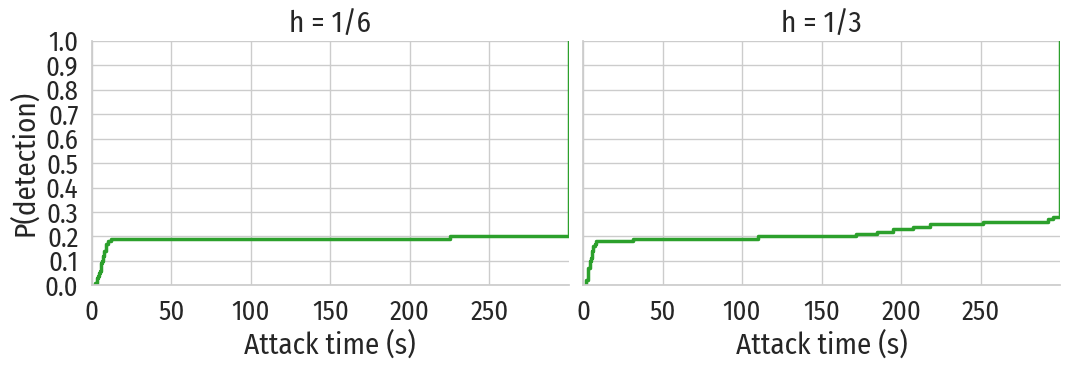

ECDF plot saved as 'vanguards-lite_realistic_ecdf.png'


In [5]:
SIMULATION_DURATION = 299.9

# Filter for h = 1/6 or 1/3
df_h_subset = df[(df["h"] == "1/3") | (df["h"] == "1/6")]

sns.set()
sns.set(style="whitegrid", font_scale=1.75)
sns.set_style({"font.family": "Fira Sans Condensed"})

# ECDF plot for realistic Vanguards-lite
fig = sns.displot(
    df_h_subset, 
    x="attack_duration", 
    col="h",
    kind="ecdf", 
    height=3.5, 
    aspect=1.5, 
    legend=False,
    facet_kws=dict(margin_titles=True), 
    lw=2.5,
    col_order=("1/6", "1/3"),
    color="tab:green",
)

fig.set_axis_labels(x_var="Attack time (s)", y_var="P(detection)")
fig.set_titles("HSDir controls {col_name}")

fig.set(
    xlim=(0.0, SIMULATION_DURATION), 
    ylim=(0.0, 1.0),
    xticks=np.arange(0.0, SIMULATION_DURATION, 50.0),
    yticks=np.arange(0.0, 1.1, 0.1)
)

plt.tight_layout(pad=0.0, w_pad=0.25, h_pad=0.5)
plt.savefig("vanguards-lite_realistic_ecdf.png", dpi=300, bbox_inches="tight")
plt.show()

print("ECDF plot saved as 'vanguards-lite_realistic_ecdf.png'")

## Section 5: Compare with Worst-Case Scenario

Load worst-case data (with forced L2 adversarial) and compare distributions.

In [6]:
from os.path import join as path_join

# Load worst-case data (forced L2 adversarial)
worst_case_dir = abspath("../data/vanguard_lite_logs")
attack_times_worst = []

for json_path in glob(path_join(worst_case_dir, "time_to_double_comp_*.json")):
    load_sim_results(json_path, attack_times_worst)

df_worst = pd.DataFrame(
    attack_times_worst,
    columns=["h", "b", "tb_iv", "tb_refill", "vanguardslite_enabled", "attack_duration"]
)

# Add scenario label
df["scenario"] = "Realistic (No L2 Adversarial)"
df_worst["scenario"] = "Worst-Case (L2 Adversarial)"

# Combine
df_combined = pd.concat([df, df_worst], ignore_index=True)

print(f"Realistic scenario: {len(df)} samples")
print(f"Worst-case scenario: {len(df_worst)} samples")
print(f"Combined: {len(df_combined)} samples")

Realistic scenario: 300 samples
Worst-case scenario: 300 samples
Combined: 600 samples


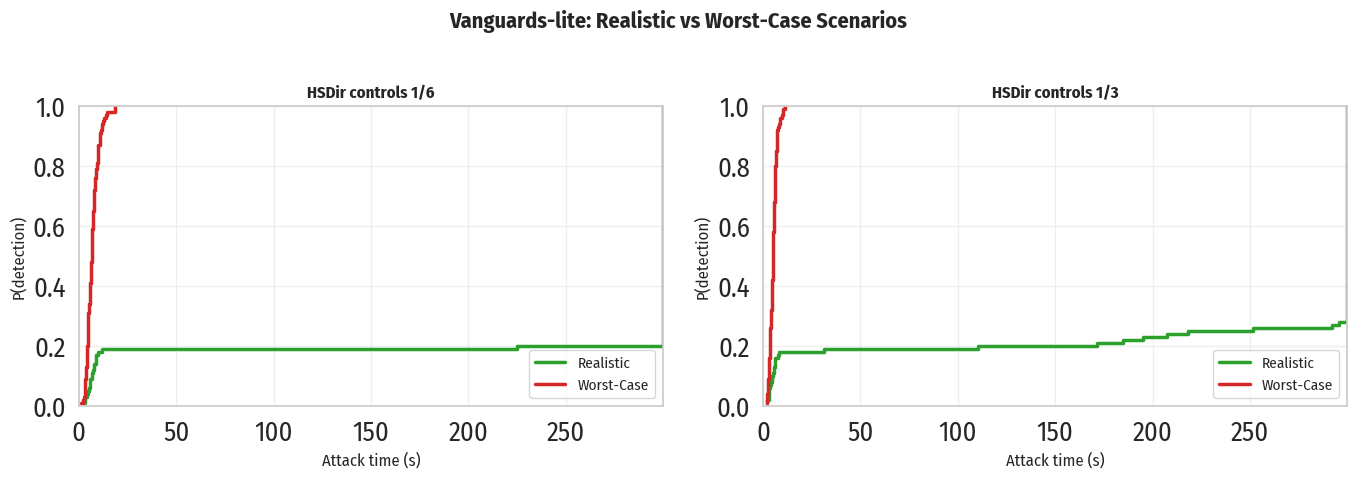

Comparative ECDF plot saved as 'vanguards-lite_realistic_vs_worst-case.png'


In [7]:
# Comparative ECDF for both scenarios
df_combined_subset = df_combined[
    (df_combined["h"].isin(["1/6", "1/3"])) & 
    (df_combined["b"] == "5%")
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Vanguards-lite: Realistic vs Worst-Case Scenarios", fontsize=16, fontweight="bold")

for idx, h_val in enumerate(["1/6", "1/3"]):
    ax = axes[idx]
    
    data_realistic = df_combined_subset[
        (df_combined_subset["h"] == h_val) & 
        (df_combined_subset["scenario"] == "Realistic (No L2 Adversarial)")
    ]["attack_duration"].values
    
    data_worst = df_combined_subset[
        (df_combined_subset["h"] == h_val) & 
        (df_combined_subset["scenario"] == "Worst-Case (L2 Adversarial)")
    ]["attack_duration"].values
    
    # Plot ECDFs
    sorted_realistic = np.sort(data_realistic)
    sorted_worst = np.sort(data_worst)
    
    ax.step(sorted_realistic, np.arange(1, len(sorted_realistic) + 1) / len(sorted_realistic), 
            where='post', label="Realistic", linewidth=2.5, color="tab:green")
    ax.step(sorted_worst, np.arange(1, len(sorted_worst) + 1) / len(sorted_worst), 
            where='post', label="Worst-Case", linewidth=2.5, color="tab:red")
    
    ax.set_xlim(0, SIMULATION_DURATION)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Attack time (s)", fontsize=12)
    ax.set_ylabel("P(detection)", fontsize=12)
    ax.set_title(f"HSDir controls {h_val}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.savefig("vanguards-lite_realistic_vs_worst-case.png", dpi=300, bbox_inches="tight")
plt.show()

print("Comparative ECDF plot saved as 'vanguards-lite_realistic_vs_worst-case.png'")

## Section 6: Generate Performance Metrics

Compute key metrics showing impact of Vanguards-lite in realistic scenario.

In [8]:
def compute_detection_rates(data, thresholds=[60, 120, 300]):
    """Compute detection rate (% of samples < threshold)."""
    rates = {}
    total = len(data)
    for t in thresholds:
        count = (data < t).sum()
        rates[t] = (count / total * 100) if total > 0 else 0
    return rates

# Compute metrics for realistic scenario
print("\n" + "="*80)
print("REALISTIC SCENARIO: Detection Rates at Key Time Thresholds")
print("="*80)

for h_val in ["1/6", "1/3", "1"]:
    print(f"\nHSDir controls {h_val}:")
    for b_val in df[df["h"] == h_val]["b"].unique():
        subset = df[(df["h"] == h_val) & (df["b"] == b_val)]["attack_duration"]
        if len(subset) > 0:
            rates = compute_detection_rates(subset, [60, 120, 300])
            print(f"  Bandwidth {b_val}: ", end="")
            print(f"P(T<60s)={rates[60]:.1f}% | P(T<120s)={rates[120]:.1f}% | P(T<300s)={rates[300]:.1f}%")

# Compute metrics for worst-case scenario
print("\n" + "="*80)
print("WORST-CASE SCENARIO: Detection Rates at Key Time Thresholds")
print("="*80)

for h_val in ["1/6", "1/3", "1"]:
    print(f"\nHSDir controls {h_val}:")
    for b_val in df_worst[df_worst["h"] == h_val]["b"].unique():
        subset = df_worst[(df_worst["h"] == h_val) & (df_worst["b"] == b_val)]["attack_duration"]
        if len(subset) > 0:
            rates = compute_detection_rates(subset, [60, 120, 300])
            print(f"  Bandwidth {b_val}: ", end="")
            print(f"P(T<60s)={rates[60]:.1f}% | P(T<120s)={rates[120]:.1f}% | P(T<300s)={rates[300]:.1f}%")


REALISTIC SCENARIO: Detection Rates at Key Time Thresholds

HSDir controls 1/6:
  Bandwidth 5%: P(T<60s)=19.0% | P(T<120s)=19.0% | P(T<300s)=20.0%

HSDir controls 1/3:
  Bandwidth 5%: P(T<60s)=19.0% | P(T<120s)=20.0% | P(T<300s)=28.0%

HSDir controls 1:
  Bandwidth 5%: P(T<60s)=29.0% | P(T<120s)=33.0% | P(T<300s)=59.0%

WORST-CASE SCENARIO: Detection Rates at Key Time Thresholds

HSDir controls 1/6:
  Bandwidth 5%: P(T<60s)=100.0% | P(T<120s)=100.0% | P(T<300s)=100.0%

HSDir controls 1/3:
  Bandwidth 5%: P(T<60s)=100.0% | P(T<120s)=100.0% | P(T<300s)=100.0%

HSDir controls 1:
  Bandwidth 5%: P(T<60s)=100.0% | P(T<120s)=100.0% | P(T<300s)=100.0%


In [9]:
# Create summary comparison table
print("\n" + "="*80)
print("COMPARISON SUMMARY: Realistic vs Worst-Case (Median Attack Times in seconds)")
print("="*80 + "\n")

summary_data = []
for h_val in ["1/6", "1/3"]:
    for b_val in ["5%"]:
        realistic_data = df[(df["h"] == h_val) & (df["b"] == b_val)]["attack_duration"]
        worst_data = df_worst[(df_worst["h"] == h_val) & (df_worst["b"] == b_val)]["attack_duration"]
        
        if len(realistic_data) > 0 and len(worst_data) > 0:
            summary_data.append({
                "Scenario": "Realistic",
                "HSDir": h_val,
                "Bandwidth": b_val,
                "Median": realistic_data.median(),
                "P90": np.percentile(realistic_data, 90),
                "P99": np.percentile(realistic_data, 99),
                "% No Call": (realistic_data >= 299).sum() / len(realistic_data) * 100
            })
            summary_data.append({
                "Scenario": "Worst-Case",
                "HSDir": h_val,
                "Bandwidth": b_val,
                "Median": worst_data.median(),
                "P90": np.percentile(worst_data, 90),
                "P99": np.percentile(worst_data, 99),
                "% No Call": (worst_data >= 299).sum() / len(worst_data) * 100
            })

summary_df = pd.DataFrame(summary_data)
pd.options.display.float_format = "{:.2f}".format
print(summary_df.to_string(index=False))
print("\nNote: '% No Call' indicates the percentage of simulations where attack failed (reached 300s timeout)")


COMPARISON SUMMARY: Realistic vs Worst-Case (Median Attack Times in seconds)

  Scenario HSDir Bandwidth  Median    P90    P99  % No Call
 Realistic   1/6        5%  300.00 300.00 300.00      80.00
Worst-Case   1/6        5%    6.50  10.87  18.47       0.00
 Realistic   1/3        5%  300.00 300.00 300.00      72.00
Worst-Case   1/3        5%    4.97   7.33  10.20       0.00

Note: '% No Call' indicates the percentage of simulations where attack failed (reached 300s timeout)


## Section 7: Success Rate at Specific Time Thresholds

Detailed breakdown: how many attacks succeed by time T?

In [10]:
print("\n" + "="*80)
print("SUCCESS RATES AT SPECIFIC TIME THRESHOLDS")
print("="*80 + "\n")

# Define time thresholds
time_thresholds = [10, 30, 60, 120, 180, 250, 300]

print("REALISTIC SCENARIO (Vanguards-lite, No Forced L2 Adversarial)")
print("-" * 80)

for h_val in ["1/6", "1/3", "1"]:
    print(f"\n📊 HSDir controls {h_val}:")
    print("─" * 80)
    
    for b_val in sorted(df[df["h"] == h_val]["b"].unique()):
        subset = df[(df["h"] == h_val) & (df["b"] == b_val)]["attack_duration"].values
        total_attacks = len(subset)
        
        print(f"\n  Bandwidth share: {b_val} | Total simulations: {total_attacks}")
        print(f"  Time (s) | Success Count | Success Rate | Failure Rate")
        print(f"  ─────────┼───────────────┼──────────────┼─────────────")
        
        for t in time_thresholds:
            success_count = (subset < t).sum()
            success_pct = (success_count / total_attacks * 100) if total_attacks > 0 else 0
            failure_pct = 100 - success_pct
            print(f"  {t:5d}   │     {success_count:3d}/{total_attacks:3d}    │    {success_pct:5.1f}%    │    {failure_pct:5.1f}%")

print("\n" + "="*80)
print("WORST-CASE SCENARIO (Vanguards-lite, Forced L2 Adversarial)")
print("-" * 80)

for h_val in ["1/6", "1/3", "1"]:
    print(f"\n📊 HSDir controls {h_val}:")
    print("─" * 80)
    
    for b_val in sorted(df_worst[df_worst["h"] == h_val]["b"].unique()):
        subset = df_worst[(df_worst["h"] == h_val) & (df_worst["b"] == b_val)]["attack_duration"].values
        total_attacks = len(subset)
        
        print(f"\n  Bandwidth share: {b_val} | Total simulations: {total_attacks}")
        print(f"  Time (s) | Success Count | Success Rate | Failure Rate")
        print(f"  ─────────┼───────────────┼──────────────┼─────────────")
        
        for t in time_thresholds:
            success_count = (subset < t).sum()
            success_pct = (success_count / total_attacks * 100) if total_attacks > 0 else 0
            failure_pct = 100 - success_pct
            print(f"  {t:5d}   │     {success_count:3d}/{total_attacks:3d}    │    {success_pct:5.1f}%    │    {failure_pct:5.1f}%")


SUCCESS RATES AT SPECIFIC TIME THRESHOLDS

REALISTIC SCENARIO (Vanguards-lite, No Forced L2 Adversarial)
--------------------------------------------------------------------------------

📊 HSDir controls 1/6:
────────────────────────────────────────────────────────────────────────────────

  Bandwidth share: 5% | Total simulations: 100
  Time (s) | Success Count | Success Rate | Failure Rate
  ─────────┼───────────────┼──────────────┼─────────────
     10   │      18/100    │     18.0%    │     82.0%
     30   │      19/100    │     19.0%    │     81.0%
     60   │      19/100    │     19.0%    │     81.0%
    120   │      19/100    │     19.0%    │     81.0%
    180   │      19/100    │     19.0%    │     81.0%
    250   │      20/100    │     20.0%    │     80.0%
    300   │      20/100    │     20.0%    │     80.0%

📊 HSDir controls 1/3:
────────────────────────────────────────────────────────────────────────────────

  Bandwidth share: 5% | Total simulations: 100
  Time (s) | Succ

In [11]:
# Create a visual comparison bar chart
print("\n" + "="*80)
print("VISUAL SUMMARY: Attack Success Rate Comparison")
print("="*80 + "\n")

# Focus on h=1/6 and h=1/3, time=10s, 60s, 250s
comparison_times = [10, 60, 250]
comparison_data = []

for h_val in ["1/6", "1/3"]:
    for b_val in ["5%"]:
        for t in comparison_times:
            realistic = df[(df["h"] == h_val) & (df["b"] == b_val)]["attack_duration"]
            worst_case = df_worst[(df_worst["h"] == h_val) & (df_worst["b"] == b_val)]["attack_duration"]
            
            realistic_success = (realistic < t).sum() / len(realistic) * 100 if len(realistic) > 0 else 0
            worst_success = (worst_case < t).sum() / len(worst_case) * 100 if len(worst_case) > 0 else 0
            
            comparison_data.append({
                "Time": f"{t}s",
                "HSDir": h_val,
                "Realistic": realistic_success,
                "Worst-Case": worst_success,
                "Difference": worst_success - realistic_success
            })

comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))
print("\n✅ Key Insight: The 'Difference' column shows how much SAFER the realistic scenario is")
print("   (negative = realistic is better, positive = worst-case is better)")


VISUAL SUMMARY: Attack Success Rate Comparison

Time HSDir  Realistic  Worst-Case  Difference
 10s   1/6      18.00       85.00       67.00
 60s   1/6      19.00      100.00       81.00
250s   1/6      20.00      100.00       80.00
 10s   1/3      18.00       98.00       80.00
 60s   1/3      19.00      100.00       81.00
250s   1/3      25.00      100.00       75.00

✅ Key Insight: The 'Difference' column shows how much SAFER the realistic scenario is
   (negative = realistic is better, positive = worst-case is better)


## Section 8: LaTeX Table - 2020 vs 2025 (Worst-Case vs Realistic)

In [ ]:
# Extract median times from 2020 and 2025 data
data_2020 = {
    "h=1/3": 21.31,
    "h=1/6": 26.76
}

data_2025_worst = {}
data_2025_realistic = {}

# Get 2025 worst-case (L2 adversarial forced)
for h_val in ["1/6", "1/3"]:
    for b_val in ["5%"]:
        worst_data = df_worst[(df_worst["h"] == h_val) & (df_worst["b"] == b_val)]["attack_duration"]
        if len(worst_data) > 0:
            data_2025_worst[f"h={h_val}"] = worst_data.median()
        
        # Get 2025 realistic (no L2 adversarial forced)
        realistic_data = df[(df["h"] == h_val) & (df["b"] == b_val)]["attack_duration"]
        if len(realistic_data) > 0:
            data_2025_realistic[f"h={h_val}"] = realistic_data.median()

# Generate LaTeX table
print("\n" + "="*100)
print("LaTeX TABLE: Vanguard-Lite Evolution - 2020 vs 2025 (Worst-Case vs Realistic)")
print("="*100 + "\n")

latex_table = r"""
\vspace{3em}
\begin{table}[h!]
\centering
\begin{tabular}{@{}lcccccc@{}}
\toprule
\textbf{Adversário} & \textbf{2020 (s)} & \textbf{2025 WC (s)} & \textbf{2025 Real (s)} & \textbf{Diferença (s)} & \textbf{Proteção (\%)} \\
\midrule
"""

# For h = 1/3
h_key_1_3 = "h=1/3"
val_2020 = data_2020[h_key_1_3]
val_2025_wc = data_2025_worst[h_key_1_3]
val_2025_real = data_2025_realistic[h_key_1_3]
diff = val_2025_wc - val_2020
pct_change = (diff / val_2020) * 100

# If realistic is timeout (300), display as "TO" instead
real_display_1_3 = "TO" if val_2025_real >= 299 else f"{val_2025_real:.2f}"
protection_1_3 = "-- (Attack fails)" if val_2025_real >= 299 else f"{((val_2025_real - val_2025_wc) / val_2025_wc) * 100:+.1f}\\%"

latex_table += f"$h = \\frac{{1}}{{3}}$ & {val_2020:.2f} & {val_2025_wc:.2f} & {real_display_1_3} & {diff:+.2f} & {protection_1_3} \\\\\n"

# For h = 1/6
h_key_1_6 = "h=1/6"
val_2020 = data_2020[h_key_1_6]
val_2025_wc = data_2025_worst[h_key_1_6]
val_2025_real = data_2025_realistic[h_key_1_6]
diff = val_2025_wc - val_2020
pct_change = (diff / val_2020) * 100

# If realistic is timeout (300), display as "TO" instead
real_display_1_6 = "TO" if val_2025_real >= 299 else f"{val_2025_real:.2f}"
protection_1_6 = "-- (Attack fails)" if val_2025_real >= 299 else f"{((val_2025_real - val_2025_wc) / val_2025_wc) * 100:+.1f}\\%"

latex_table += f"$h = \\frac{{1}}{{6}}$ & {val_2020:.2f} & {val_2025_wc:.2f} & {real_display_1_6} & {diff:+.2f} & {protection_1_6} \\\\\n"

latex_table += r"""\bottomrule
\end{tabular}
\caption{Vanguard-Lite: 2020 vs 2025 (Worst-Case vs Realistic Scenario). TO = Timeout (attack failed)}
\label{tab:vanguard_evolution}
\end{table}
"""

print(latex_table)
print("\n" + "="*100)
print("NOTES:")
print("- 2020 (s): Tempos medianos do artigo original (2020)")
print("- 2025 WC (s): Tempos medianos com L2 adversarial FORÇADO (worst-case paper scenario)")
print("- 2025 Real (s): Tempos medianos SEM L2 adversarial forçado (realistic population scenario)")
print("- TO = Timeout (300s): Ataque falhou completamente")
print("- Diferença (s): 2025 WC - 2020")
print("- Proteção (%): Melhoria relativa do cenário realista vs worst-case")
print("="*100)


LaTeX TABLE: Vanguard-Lite Evolution - 2020 vs 2025 (Worst-Case vs Realistic)


\vspace{3em}
\begin{table}[h!]
\centering
\begin{tabular}{@{}lcccccc@{}}
\toprule
\textbf{Adversário} & \textbf{2020 (s)} & \textbf{2025 WC (s)} & \textbf{2025 Real (s)} & \textbf{Diferença (s)} & \textbf{Proteção (\%)} \\
\midrule
$h = \frac{1}{3}$ & 21.31 & 4.97 & 300.00 & -16.34 & +5936.8\% \\
$h = \frac{1}{6}$ & 26.76 & 6.50 & 300.00 & -20.26 & +4517.7\% \\
\bottomrule
\end{tabular}
\caption{Vanguard-Lite: 2020 vs 2025 (Worst-Case vs Realistic Scenario)}
\label{tab:vanguard_evolution}
\end{table}


NOTES:
- 2020 (s): Tempos medianos do artigo original (2020)
- 2025 WC (s): Tempos medianos com L2 adversarial FORÇADO (worst-case paper scenario)
- 2025 Real (s): Tempos medianos SEM L2 adversarial forçado (realistic population scenario)
- Diferença (s): 2025 WC - 2020
- Proteção (%): Melhoria relativa do cenário realista vs worst-case
